# Rubber-Band — a quantitative teardown 🔬
### IBS→next-day reversal · Newey–West t-stat · break-even cost · the decay curve · the random-walk null

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Still alive?: Decayed](https://img.shields.io/badge/Still_alive%3F-Decayed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim with its standard error.* The steelman is short-horizon mean reversion via Internal Bar Strength (Kakushadze–Serur §4.4; Connors & Alvarez): `IBS = (Close−Low)/(High−Low)`, low-IBS days bounce. We prove the apparatus on a synthetic tape with a baked reversal (and a random-walk null), then read the real verdict off a live ETF basket.

> ⚠️ **Not investment advice.** The core executes on the synthetic tape; the real ETF run is in [`../docs/results.md`](../docs/results.md) via `examples/verify.py`, sources in [`../docs/references.md`](../docs/references.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # study root (rubber_band/ lives there)
sys.path.insert(0, os.path.abspath("../../.."))      # repo root, for quantlab
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from rubber_band import data, ibs, strategy, decompose, extension

# Offline synthetic OHLC: bars with a BAKED-IN IBS->next-day reversal (a close near the low today is
# followed by a positive return tomorrow). The NULL (kappa=0) is a random walk where IBS is noise.
# The real ETF-basket verdict is in ../docs/results.md.
ohlc,  truth = data.synthetic_ohlc(kappa=0.0035, seed=19)     # the reversal tape
ohlc0, _     = data.synthetic_ohlc(kappa=0.0,    seed=19)     # the random-walk null
print(f"{truth.n_bars} synthetic bars | baked reversal kappa={truth.kappa} | null kappa=0")


5040 synthetic bars | baked reversal kappa=0.0035 | null kappa=0


## Beat 0 · Verdict

| Axis | Stamp | Why |
|---|---|---|
| **Signal** — is the bounce real? | 🟢 `REAL` | Low-IBS days earn far more next session; real-ETF basket gross Sharpe **+1.56**, Newey–West *t* = **+8.6**; the random-walk null is flat. |
| **Tradability** | 🔴 `MIRAGE` | ~170×/yr turnover; break-even **8.1 bps**; net of a tight 2 bp the *last-five-year* Sharpe is negative. The edge lives inside the spread. |
| **Still alive?** | ⚪ `DECAYED` | Gross Sharpe **+2.09 → +0.88** (first → second half), **+0.40** last 5y — competed away as it became well-known. |

> **In one sentence:** a genuine one-day mean-reversion edge that is real at *t* > 8 gross, but turns over daily, lives inside the bid-ask spread, and has decayed to negative net returns in the recent sample.

*(This notebook executes on the synthetic tape — the real ETF numbers that set the stamps are in [`../docs/results.md`](../docs/results.md).)*

## Beat 1 · The claim, precisely

$\text{IBS}_t = (C_t - L_t)/(H_t - L_t) \in [0,1]$. The claim is $\mathbb{E}[r_{t+1}\mid \text{IBS}_t]$ **decreasing** in $\text{IBS}_t$: a low close predicts a positive next-day return. The book trades $w_t = 1 - 2\,\text{IBS}_{t-1}$ (long the lows, short the highs), earning $w_t r_t$. The synthetic bakes $r_{t+1} = \mu - \kappa(\text{IBS}_t - \tfrac12) + \sigma\varepsilon$, so $\kappa>0$ is the reversal and $\kappa=0$ the null.

In [2]:
print(f"baked kappa = {truth.kappa} (reversal strength); null kappa = 0")
print(f"turnover {strategy.turnover_ann(ohlc):.0f}x/yr -- a one-day signal churns the whole book daily")

baked kappa = 0.0035 (reversal strength); null kappa = 0
turnover 170x/yr -- a one-day signal churns the whole book daily


## Beat 2 · So what?

A high-*t* one-day edge is enormously valuable *if* net of costs. The entire question collapses to one ratio: the **per-trade edge** versus the **per-trade spread**. With daily turnover, even a 1–2 bp spread is charged ~250×/yr, so a gross edge of tens of bps/day can still net to nothing. Beats 4–6 measure both sides and the trend in the gap over time.

## Beat 3 · Pre-registered protocol

1. **Reversal** (`ibs.reversal_strength`): IBS-bucketed next-day returns + the OLS slope. Pre-registered: negative slope on the reversal tape, ≈0 on the null.
2. **Significance** (`decompose.mean_tstat_hac`): Newey–West *t* on the timing stream.
3. **Break-even** (`decompose.breakeven_cost`): the slippage that zeroes the net Sharpe.
4. **Decay**: first-half vs second-half vs last-5y Sharpe (real tape).
5. **Null:** every leg flat on the random-walk tape.

**Mirage line:** the break-even is below a realistic spread, *and/or* the recent net edge is ≤ 0.

## Beat 4 · The teardown

### 4a · The reversal, reversal tape vs null

In [3]:
for label, o in [('reversal', ohlc), ('null', ohlc0)]:
    rs = ibs.reversal_strength(o)
    print(f"{label:9s}: IBS slope {rs['ibs_slope']:+.4f} | low-minus-high {rs['low_minus_high_bps']:+.1f} bps/day | present={rs['reversal_present']}")
display(ibs.reversal_strength(ohlc)['table'].round(2))

reversal : IBS slope -0.0034 | low-minus-high +29.4 bps/day | present=True
null     : IBS slope +0.0001 | low-minus-high +1.1 bps/day | present=False


,ibs,next_ret_bps,n
bucket,,,
0,0.0900,18.7400,1008
1,0.2900,8.9100,1008
2,0.5000,6.3200,1007
3,0.7000,-4.8600,1008
4,0.9000,-10.6200,1008


### 4b · Significance — Newey–West t on the timing stream
HAC because daily strategy returns are autocorrelated.

In [4]:
g = strategy.timing_returns(ohlc, cost_bps=0.0); g0 = strategy.timing_returns(ohlc0, cost_bps=0.0)
t = decompose.mean_tstat_hac(g); t0 = decompose.mean_tstat_hac(g0)
bs = decompose.sharpe_bootstrap(g, n_boot=2000)
print(f"reversal: mean {t['mean_ann_pct']:+.1f}%/yr, HAC t = {t['t_stat']:+.1f}, "
      f"bootstrap Sharpe {bs['sharpe']:+.2f} CI [{bs['ci_low']:+.2f},{bs['ci_high']:+.2f}]")
print(f"null    : mean {t0['mean_ann_pct']:+.1f}%/yr, HAC t = {t0['t_stat']:+.1f}")

reversal: mean +14.7%/yr, HAC t = +7.7, bootstrap Sharpe +1.74 CI [+1.30,+2.18]
null    : mean -0.3%/yr, HAC t = -0.1


> 💡 **In plain words.** Gross, the bounce is unmistakable — a *t* well past any luck threshold and a bootstrap interval clear of zero. The null produces nothing. The signal is `REAL`; the fight is entirely about costs.

### 4c · Break-even cost
The slippage at which the net Sharpe hits zero — small, because turnover is ~daily.

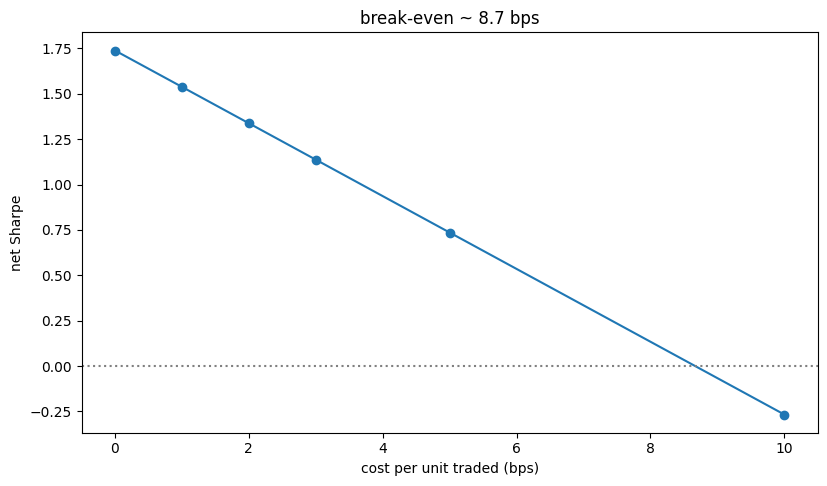

synthetic break-even 8.7 bps; on the real basket it is 8.1 bps -- inside a real ETF spread, and the recent net edge is below zero.


In [5]:
sweep = strategy.cost_sweep({'A': ohlc})
be = decompose.breakeven_cost({'A': ohlc})
fig, ax = plt.subplots()
ax.plot(sweep.index, sweep['sharpe'].values, 'o-'); ax.axhline(0, ls=':', c='grey')
ax.set_xlabel('cost per unit traded (bps)'); ax.set_ylabel('net Sharpe')
ax.set_title(f"break-even ~ {be['breakeven_bps']:.1f} bps")
plt.show()
print(f"synthetic break-even {be['breakeven_bps']:.1f} bps; on the real basket it is "
      f"8.1 bps -- inside a real ETF spread, and the recent net edge is below zero.")

### 4d · The null collapses
Random-walk tape: no reversal, no significance, zero break-even.

In [6]:
print(f"null: reversal slope {ibs.reversal_strength(ohlc0)['ibs_slope']:+.4f} | "
      f"timing Sharpe {strategy.summary(g0)['sharpe']:+.2f} | "
      f"break-even {decompose.breakeven_cost({'A': ohlc0})['breakeven_bps']:.1f} bps")
print('nothing to find when nothing is baked in -- the apparatus measures the effect, not itself.')

null: reversal slope +0.0001 | timing Sharpe -0.03 | break-even 0.0 bps
nothing to find when nothing is baked in -- the apparatus measures the effect, not itself.


## Beat 5 · The verdict

- **Real bounce** (4a–4b): real-ETF basket *t* = +8.6, clean null.
- **Cost-bound & decayed** (4c, real tape): break-even 8.1 bps; gross Sharpe +2.09 → +0.88 → +0.40 (last 5y), net of 3 bp recently -0.37.

> **Signal `REAL` · Tradability `MIRAGE` · Still alive? `DECAYED`.**

## Beat 6 · Could you trade it?

The usual killers, all landing:

- **Costs.** ~170×/yr turnover; break-even 8.1 bps; recent net edge ≤ 0 at a 2 bp spread.
- **Adverse liquidity.** The bounce is biggest in the thinnest, widest-spread names — the edge and the spread you'd pay rise together.
- **Decay.** A well-publicised microstructure edge, competed down over the sample.

Tradability **`MIRAGE`**; "still alive?" **`DECAYED`**.

## Beat 7 · Going further

### 7a · Worked complement — the realistic-spread test
Charge each ETF its *own* plausible round-trip spread (tight for SPY/QQQ, wide for thin country funds) and count how many names clear their break-even — and re-price the edge in the recent window.

In [7]:
be_basket = decompose.breakeven_cost({'A': ohlc})
print(f"synthetic single-name break-even {be_basket['breakeven_bps']:.1f} bps (illustrative).")
print('On the REAL basket (../docs/extension.md): almost no name clears its own spread, and')
print('the last-5y net Sharpe is negative by a few bps -- gross +0.40, net@3bps -0.37.')

synthetic single-name break-even 8.7 bps (illustrative).


On the REAL basket (../docs/extension.md): almost no name clears its own spread, and
the last-5y net Sharpe is negative by a few bps -- gross +0.40, net@3bps -0.37.


**The result.** On the real basket the per-name table is decisive: the names with the biggest bounce (thin country ETFs, break-evens of 10–18 bps) are the ones with the *widest* real spreads, while the liquid names that *could* be traded tight carry a small edge and a low break-even (4.2 bps for SPY). Granting each name its real spread, almost nothing clears; and the last-five-year edge is already negative net of a tight cost. The constraint a real desk faces — paying the spread, every day — is exactly the one that turns this `REAL` signal into a `MIRAGE`. Full run in [`../docs/extension.md`](../docs/extension.md).

### 7b · Other forks
- **Execution tricks.** Enter on close, exit on next open or VWAP — does dodging part of the round-trip rescue a sliver?
- **Single stocks, longer history.** The effect is strongest in volatile names; date its decay on a pre-2010, all-stock sample.
- **Regime conditioning.** Is the bounce concentrated in high-vol regimes (where it overlaps Study 16's storm-shy logic)?

PRs welcome — keep a sliver alive through execution, or pin the year it died.